# Chapter 1

## Question 1

% Briefly explain partialling-out and the adaptivity property
% for the linear regression model, and use the gender wage
% gap data to illustrate your points. Present your discussion
% as a brief section of a professionally done empirical paper.

In [1]:
using CSV, DataFrames, RegressionTables, Econometrics, Random, LinearAlgebra, Distributions, Plots, BasicInterpolators, StatsPlots

In [ ]:
output_path = "./14.382_PSet1" # set path to save output files

"/Users/filippopaternollo/Dropbox/Applicazioni/Overleaf/Psets 14.382/PS1"

In [3]:
seed = Random.seed!(20260219)
seed

TaskLocalRNG()

In [4]:
CPSdata = CSV.read("../../../Students2022/Data/CPS2015/CPS2015.csv", DataFrame)

Row,Column1,wage,lnw,widowed,divorced,separated,nevermarried,married,weight,female,lhs,hsg,sc,cg,ad,mw,so,we,ne,exp1,exp2,exp3,exp4,occ,occ2,ind,ind2
,Int64,Float64,Float64,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Int64
1,1,10.989,2.3969,0,0,0,0,1,690.05,0,0,0,1,0,0,0,0,0,1,26.0,6.76,17.576,45.6976,9130.0,22,490.0,2
2,2,15.8654,2.76414,0,0,0,0,1,785.82,1,0,1,0,0,0,0,0,0,1,26.0,6.76,17.576,45.6976,930.0,2,9380.0,22
3,3,36.0577,3.58512,0,0,0,0,1,785.82,0,0,0,1,0,0,0,0,0,1,38.0,14.44,54.872,208.514,430.0,1,9470.0,22
4,4,14.4231,2.66883,0,1,0,0,0,429.88,0,0,1,0,0,0,0,0,0,1,24.0,5.76,13.824,33.1776,100000.0,17,2280.0,5
5,5,27.7778,3.32424,0,0,0,0,1,840.38,0,0,0,0,1,0,0,0,0,1,24.0,5.76,13.824,33.1776,230.0,1,7890.0,17
6,6,24.0385,3.17966,0,0,0,0,1,840.38,1,0,1,0,0,0,0,0,0,1,36.0,12.96,46.656,167.962,630.0,2,2290.0,5
7,7,25.9615,3.25662,0,0,0,0,1,466.0,0,0,0,1,0,0,0,0,0,1,19.0,3.61,6.859,13.0321,3850.0,12,9470.0,22
8,8,9.61538,2.26336,0,0,0,0,1,856.43,1,0,1,0,0,0,0,0,0,1,33.0,10.89,35.937,118.592,4760.0,16,5380.0,9
9,9,22.1154,3.09627,0,1,0,0,0,904.05,1,0,0,0,1,0,0,0,0,1,17.0,2.89,4.913,8.3521,3255.0,10,8090.0,18


Regression of `lnw` on `female` controlling for `married`

In [5]:
long = fit(EconometricModel, @formula(lnw ~ female + married), CPSdata)

femaleonmarried = fit(EconometricModel, @formula(female ~ married), CPSdata, vce=HC1)
female_resid = residuals(femaleonmarried)

lnwonmarried = fit(EconometricModel, @formula(lnw ~ married), CPSdata, vce=HC1)
lnw_resid = residuals(lnwonmarried)

CPSdata.female_resid = female_resid
CPSdata.lnw_resid = lnw_resid

residualizedX = fit(EconometricModel, @formula(lnw ~ 0 + female_resid), CPSdata, vce=HC1)
residualisedYandX = fit(EconometricModel, @formula(lnw_resid ~ 0 + female_resid), CPSdata, vce=HC1)

regtable(long, residualizedX, residualisedYandX)


------------------------------------------------
                        lnw            lnw_resid
               ---------------------   ---------
                     (1)         (2)         (3)
------------------------------------------------
(Intercept)     3.103***                        
                 (0.007)                        
female         -0.221***                        
                 (0.007)                        
married         0.215***                        
                 (0.007)                        
female_resid               -0.221***   -0.221***
                             (0.036)     (0.007)
------------------------------------------------
N                 32,523      32,523      32,523
R2                 0.062       0.491       0.032
------------------------------------------------



In [6]:
regtable(long, residualizedX, residualisedYandX, render = LatexTable(), file="$output_path/chapter1q1regtable.tex");

## Question 2

In [7]:
function msqrt(C::AbstractMatrix{<:Real})
"""
Computes square root of a symmetric positive definite matrix using eigenvalue decomposition.
"""
    F = eigen(C)
    vals = sqrt.(F.values)
    F.vectors * Diagonal(vals) * F.vectors'
end

msqrt (generic function with 1 method)

In [8]:
function qtmax(C::AbstractMatrix{<:Real}, S::Integer, alpha::Real; rng=Random.default_rng())
"""
Simulates max |N(0, C)| draws and returns the (1-alpha) quantile.
"""
    p = size(C, 1)
    @assert size(C, 2) == p "C must be square"

    Z = randn(rng, p, S)                 # p x S
    T = abs.(msqrt(C) * Z)               # p x S
    tmaxs = vec(maximum(T, dims=1))      # length S
    quantile(tmaxs, 1 - alpha)
end

qtmax (generic function with 1 method)

In [9]:
# Make controls factor variables
CPSdata.educ = categorical(
    CPSdata.lhs .+ 2 .* CPSdata.hsg .+ 3 .* CPSdata.sc .+ 4 .* CPSdata.cg .+ 5 .* CPSdata.ad,
    ordered=true,
    levels=[1,2,3,4,5]
);
CPSdata.ms = categorical(
    CPSdata.married .+ 2 .* CPSdata.widowed .+ 2 .* CPSdata.separated .+ 3 .* CPSdata.divorced .+ 4 .* CPSdata.nevermarried,
    ordered=true,
    levels=[1,2,3,4]
);
CPSdata.reg = categorical(
    CPSdata.ne .+ 2 .* CPSdata.mw .+ 3 .* CPSdata.so .+ 4 .* CPSdata.we,
    ordered=true,
    levels=[1,2,3,4]
);

Regress  $\log(wage)$ on $female$ dummy, $female \times marital status$ and controls. Use White standard errors

In [10]:
ols_interactions = fit(EconometricModel,
    @formula(lnw ~ female&ms +
             exp1 + exp2 + exp3 + exp4 + educ + occ2 + ind2 + ms + reg +
             exp1*(educ + occ2 + ind2 + ms + reg) +
             exp2*(educ + occ2 + ind2 + ms + reg) +
             exp3*(educ + occ2 + ind2 + ms + reg) +
             exp4*(educ + occ2 + ind2 + ms + reg)),
    CPSdata, vce=HC0)
regtable(ols_interactions, keep = [r"female"])


--------------------------
                    lnw   
--------------------------
female & ms: 1   -0.289***
                   (0.007)
female & ms: 2   -0.182***
                   (0.036)
female & ms: 3   -0.226***
                   (0.017)
female & ms: 4   -0.106***
                   (0.014)
--------------------------
Controls               Yes
--------------------------
N                   32,523
R2                   0.303
--------------------------



In [11]:
HCV_coefs = vcov(ols_interactions, HC0)
full_se = sqrt.(diag(HCV_coefs))

D = Diagonal(1.0 ./ full_se)
C_coefs = D * HCV_coefs * D
coef_names = coefnames(ols_interactions)
coef_vals  = coef(ols_interactions)

female_indices = findall(occursin.("female", coef_names))
tes    = coef_vals[female_indices]
tes_se = full_se[female_indices]
tes_cor = C_coefs[female_indices, female_indices]


4×4 Matrix{Float64}:
 1.0        0.009109    0.0287092   0.0287485
 0.009109   1.0         0.00275159  0.0073833
 0.0287092  0.00275159  1.0         0.0115532
 0.0287485  0.0073833   0.0115532   1.0

In [12]:
S = 100000; # Number of simulations to estimate the critical value
alpha = .1; # Significance level
crit_val = qtmax(tes_cor,S,alpha, rng=seed)

2.229465860021997

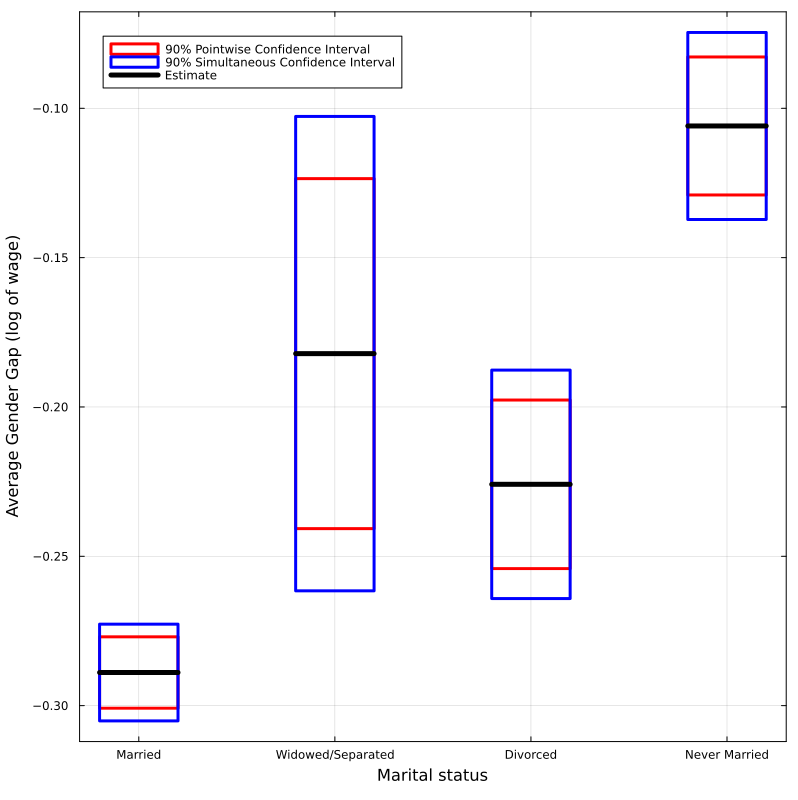

"/Users/filippopaternollo/Dropbox/Applicazioni/Overleaf/Psets 14.382/PS1/Gender-gap-by-ms-CB-controls-interacted.pdf"

In [13]:
tes_ucb = tes .+ crit_val .* tes_se
tes_lcb = tes .- crit_val .* tes_se

tes_uci = tes .+ quantile(Normal(), 1 - alpha/2) .* tes_se
tes_lci = tes .+ quantile(Normal(), alpha/2) .* tes_se

# Helper to draw unfilled rectangle
rectshape(xl, xr, yb, yt) = Shape([xl, xr, xr, xl], [yb, yb, yt, yt])

x = 1:4
p = plot(
    xticks=(x, ["Married", "Widowed/Separated", "Divorced", "Never Married"]),
    xlabel="Marital status",
    ylabel="Average Gender Gap (log of wage)",
    legend=:topleft,
    size=(800, 800),
    framestyle=:box
)

for i in x
    # 90% pointwise CI (red)
    plot!(p, rectshape(i-0.2, i+0.2, tes_lci[i], tes_uci[i]),
          fillalpha=0, linecolor=:red, linewidth=3,
          label=(i == 1 ? "90% Pointwise Confidence Interval" : ""))

    # 90% simultaneous CI (blue)
    plot!(p, rectshape(i-0.2, i+0.2, tes_lcb[i], tes_ucb[i]),
          fillalpha=0, linecolor=:blue, linewidth=3,
          label=(i == 1 ? "90% Simultaneous Confidence Interval" : ""))

    # estimate segment (black)
    plot!(p, [i-0.2, i+0.2], [tes[i], tes[i]],
          color=:black, linewidth=5,
          label=(i == 1 ? "Estimate" : ""))
end
display(p)

savefig(p, "$output_path/Gender-gap-by-ms-CB-controls-interacted.pdf")

# Chapter 3

## Question 2

Montecarlo

In [15]:
# First stage and structural coefficient
γ = 1;
β = 2;

In [16]:
S = 100000
N = 1000

iv_βs = zeros(S)
Zs = rand(seed, N, S)
εs = randn(seed, N, S)

for s in 1:S
    Z = Zs[:, s];
    ε = εs[:, s];
    X = γ*Z + ε;
    Y = β*X + ε;
    iv_βs[s] = dot(Z, Y) / dot(Z, X)
end

In [17]:
γ_weak = 1/4
weak_iv_βs = zeros(S)
for s in 1:S
    Z = Zs[:, s];
    ε = εs[:, s];
    X = γ_weak*Z + ε;
    Y = β*X + ε;
    weak_iv_βs[s] = dot(Z, Y) / dot(Z, X)
end

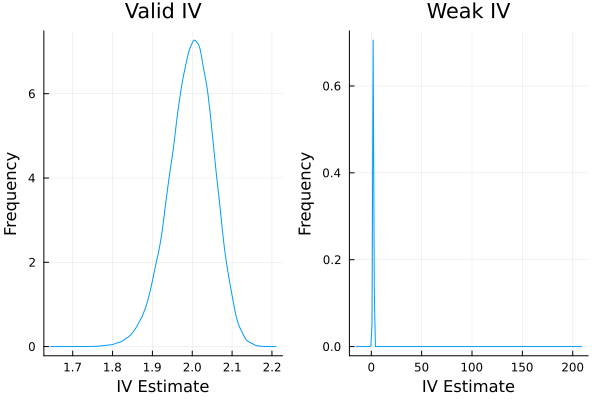

"/Users/filippopaternollo/Dropbox/Applicazioni/Overleaf/Psets 14.382/PS1/IV-estimate-distributions.pdf"

In [19]:
p = plot(density(iv_βs, xlabel="IV Estimate", ylabel="Frequency", label="", title="Valid IV"),
density(weak_iv_βs, xlabel="IV Estimate", ylabel="Frequency", title="Weak IV", label=""),layout=(1,2))
display(p)
savefig(p, "$output_path/IV-estimate-distributions.pdf")